In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Sample-Superstore.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Sample-Superstore.csv'

In [3]:
import os
os.listdir()

['.ipynb_checkpoints', 'Sample - Superstore.csv', 'Untitled.ipynb']

In [4]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv")
df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 2944: invalid start byte

In [5]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(9994, 21)

In [14]:
df["Sales"].sum()

np.float64(2297200.8603000003)

In [15]:
df["Order ID"].nunique()

5009

In [16]:
df["Sales"].mean()

np.float64(229.85800083049833)

In [17]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [18]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [19]:
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

In [22]:
import matplotlib.pyplot as plt

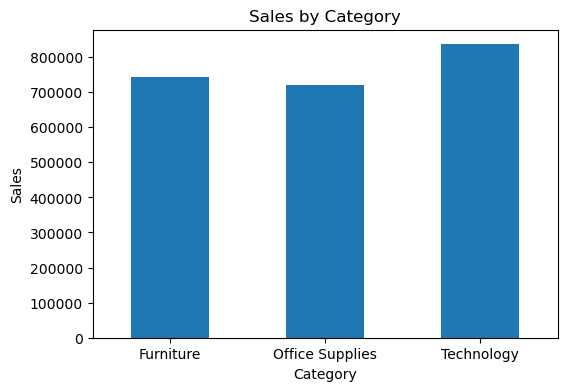

In [23]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar", figsize=(6,4))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

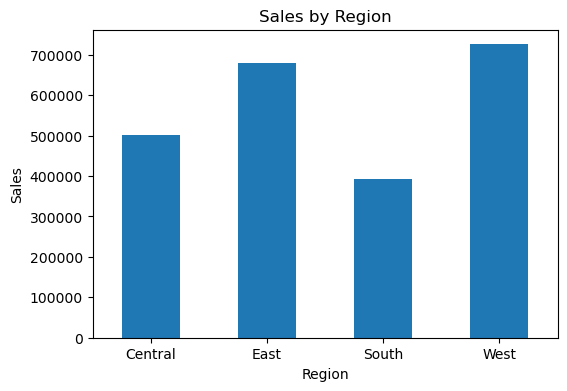

In [24]:
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar", figsize=(6,4))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

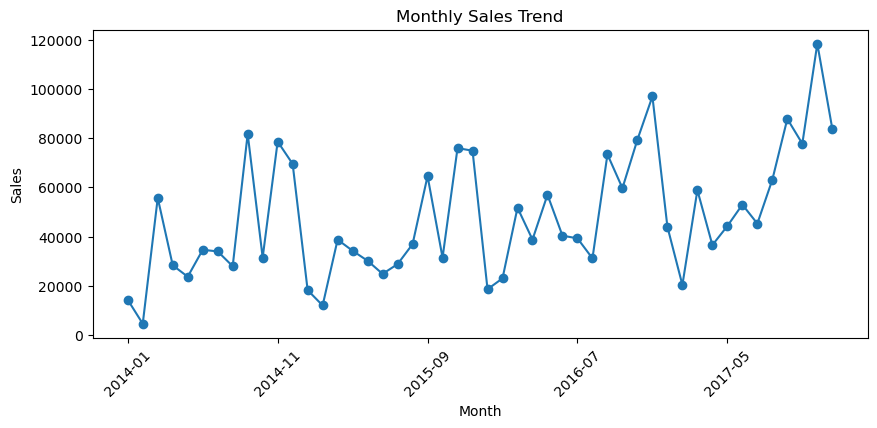

In [25]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.plot(kind="line", marker="o", figsize=(10,4))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

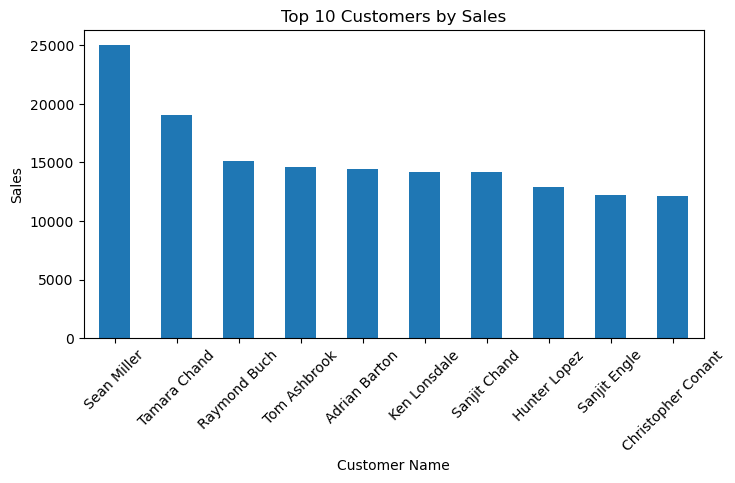

In [26]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind="bar", figsize=(8,4))

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer Name")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

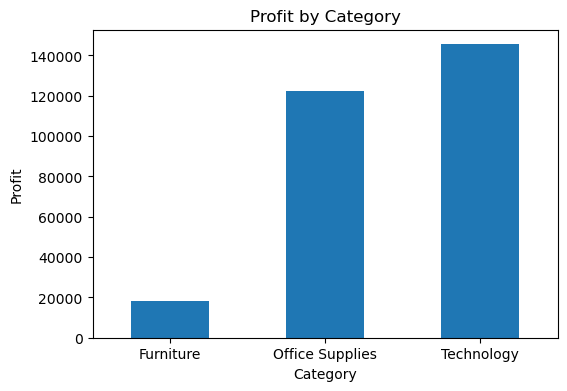

In [27]:
profit_category = df.groupby("Category")["Profit"].sum()

profit_category.plot(kind="bar", figsize=(6,4))

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

Business Insights

Technology category generated the highest sales among all product categories.

The West region showed the strongest sales performance.

Monthly sales trends indicate that sales increased during specific months, showing seasonal demand.

A small group of top customers contributed a significant portion of total sales.

Profit performance varies across categories, indicating opportunities to improve pricing and marketing strategies.

Dashboard Summary

This Sales Data Analysis Dashboard was created using Python, Pandas, and Matplotlib. The project involved cleaning the dataset, performing exploratory data analysis, creating visualizations, and identifying key business insights. The dashboard helps businesses understand sales trends, customer behavior, and regional performance to support better decision-making.